Allison Evanich

## Business Problem
This notebook analyzes synthetic healthcare claims data to identify patterns associated with claim outcomes and to evaluate whether a machine learning model can predict whether a claim will be paid, denied, or partially paid.

## Data Explanation
The dataset includes 1,000 synthetic healthcare claims with financial, coding, insurance, and administrative variables. The target variable is `Outcome`.

## Methods
This analysis includes exploratory data analysis, feature engineering, and supervised machine learning classification using logistic regression and random forest.

## Ethical Assessment
Because the dataset is synthetic, it is appropriate for training and education. However, real-world deployment would require careful review for bias, transparency, and data leakage.

## 1. Load and Inspect Data

In [215]:
# imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [216]:
# load data

df = pd.read_csv("C:/Users/Allis/Downloads/claim_data.csv")

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (1000, 15)


,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Claim ID            1000 non-null   object
 1   Provider ID         1000 non-null   int64 
 2   Patient ID          1000 non-null   int64 
 3   Date of Service     1000 non-null   object
 4   Billed Amount       1000 non-null   int64 
 5   Procedure Code      1000 non-null   int64 
 6   Diagnosis Code      1000 non-null   object
 7   Allowed Amount      1000 non-null   int64 
 8   Paid Amount         1000 non-null   int64 
 9   Insurance Type      1000 non-null   object
 10  Claim Status        1000 non-null   object
 11  Reason Code         1000 non-null   object
 12  Follow-up Required  1000 non-null   object
 13  AR Status           1000 non-null   object
 14  Outcome             1000 non-null   object
dtypes: int64(6), object(9)
memory usage: 117.3+ KB


None

In [217]:
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nOutcome distribution:")
display(df["Outcome"].value_counts())

print("\nUnique values per column:")
display(df.nunique().sort_values(ascending=False))


Column names:
['Claim ID', 'Provider ID', 'Patient ID', 'Date of Service', 'Billed Amount', 'Procedure Code', 'Diagnosis Code', 'Allowed Amount', 'Paid Amount', 'Insurance Type', 'Claim Status', 'Reason Code', 'Follow-up Required', 'AR Status', 'Outcome']

Missing values:


Claim ID              0
Provider ID           0
Patient ID            0
Date of Service       0
Billed Amount         0
Procedure Code        0
Diagnosis Code        0
Allowed Amount        0
Paid Amount           0
Insurance Type        0
Claim Status          0
Reason Code           0
Follow-up Required    0
AR Status             0
Outcome               0
dtype: int64


Outcome distribution:


Outcome
Paid              357
Denied            331
Partially Paid    312
Name: count, dtype: int64


Unique values per column:


Claim ID              1000
Provider ID           1000
Patient ID            1000
Billed Amount          363
Allowed Amount         332
Paid Amount            311
Date of Service        143
Diagnosis Code         100
Procedure Code          10
Reason Code              8
AR Status                6
Insurance Type           4
Claim Status             3
Outcome                  3
Follow-up Required       2
dtype: int64

## 2. Data cleaning and feature engineering

In [219]:
# Make a copy so the original stays unchanged
claims = df.copy()

# Standardize column names
claims.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in claims.columns]

# Convert date
claims["Date_of_Service"] = pd.to_datetime(claims["Date_of_Service"], errors="coerce")

# Basic date features
claims["service_year"] = claims["Date_of_Service"].dt.year
claims["service_month"] = claims["Date_of_Service"].dt.month
claims["service_dayofweek"] = claims["Date_of_Service"].dt.day_name()

# Financial engineered features for analysis
claims["payment_ratio"] = np.where(
    claims["Billed_Amount"] > 0,
    claims["Paid_Amount"] / claims["Billed_Amount"],
    np.nan
)

claims["allowed_ratio"] = np.where(
    claims["Billed_Amount"] > 0,
    claims["Allowed_Amount"] / claims["Billed_Amount"],
    np.nan
)

claims["billed_minus_paid"] = claims["Billed_Amount"] - claims["Paid_Amount"]
claims["billed_minus_allowed"] = claims["Billed_Amount"] - claims["Allowed_Amount"]

print("Cleaned dataset shape:", claims.shape)
display(claims.head())

Cleaned dataset shape: (1000, 22)


,Claim_ID,Provider_ID,Patient_ID,Date_of_Service,Billed_Amount,Procedure_Code,Diagnosis_Code,Allowed_Amount,Paid_Amount,Insurance_Type,...,Follow_up_Required,AR_Status,Outcome,service_year,service_month,service_dayofweek,payment_ratio,allowed_ratio,billed_minus_paid,billed_minus_allowed
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,Self-Pay,...,Yes,Pending,Partially Paid,2024,8,Wednesday,0.667763,0.717105,101,86
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,Medicare,...,Yes,Open,Denied,2024,6,Friday,0.591954,0.620690,142,132
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,235,99213,A00.1,148,119,Commercial,...,No,Denied,Denied,2024,7,Thursday,0.506383,0.629787,116,87
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,112,99215,A18.6,79,69,Medicare,...,No,Partially Paid,Denied,2024,5,Sunday,0.616071,0.705357,43,33
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,406,99238,A17.9,320,259,Medicare,...,No,On Hold,Denied,2024,7,Tuesday,0.637931,0.788177,147,86


## Data dictionary / appendix support

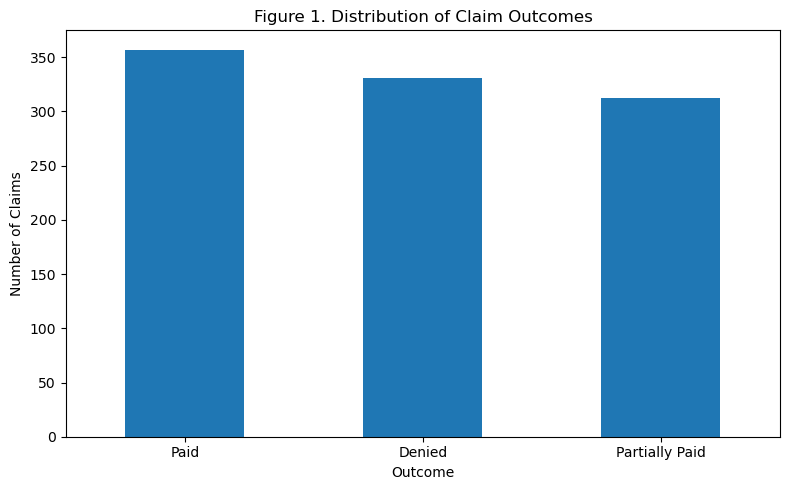

Outcome
Paid              357
Denied            331
Partially Paid    312
Name: count, dtype: int64

In [221]:
# Figure 1 — Outcome distribution

outcome_counts = claims["Outcome"].value_counts()

plt.figure(figsize=(8, 5))
outcome_counts.plot(kind="bar")
plt.title("Figure 1. Distribution of Claim Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outcome_distribution.png', bbox_inches='tight')
plt.show()

display(outcome_counts)

The distribution of claim outcomes shows that the majority of claims
are paid, while a smaller portion are denied or partially paid.
This imbalance is typical in healthcare billing datasets and may
affect model performance.

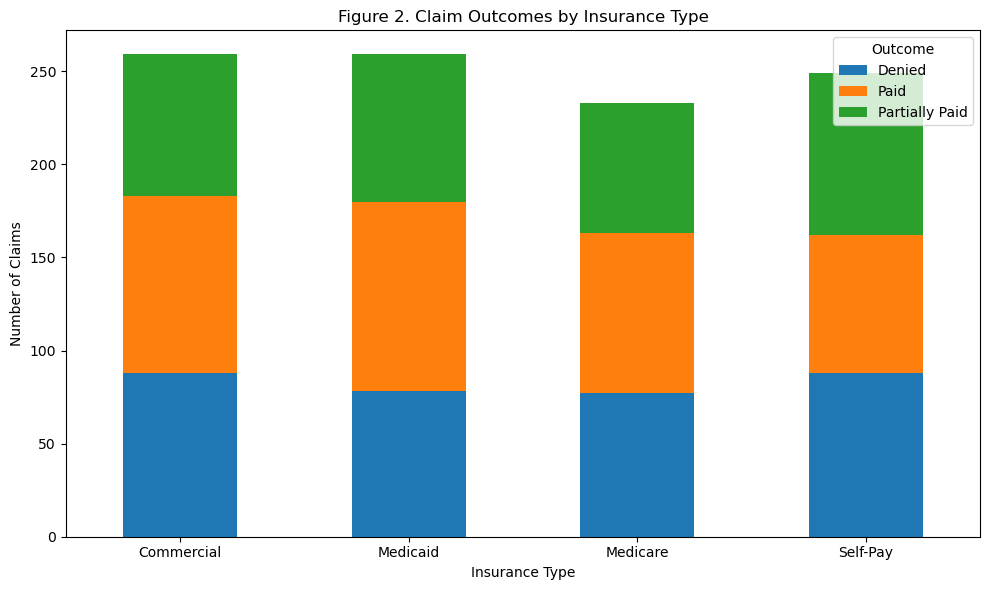

Outcome,Denied,Paid,Partially Paid
Insurance_Type,,,
Commercial,88,95,76
Medicaid,78,102,79
Medicare,77,86,70
Self-Pay,88,74,87


In [223]:
# Figure 2 — Outcome by insurance type

insurance_outcome = pd.crosstab(claims["Insurance_Type"], claims["Outcome"])

insurance_outcome.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Figure 2. Claim Outcomes by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig('outcome_by_insurance_type.png', bbox_inches='tight')
plt.show()

display(insurance_outcome)

This visualization compares claim outcomes across different insurance types. The stacked bar chart highlights how the proportion of paid, denied, and partially paid claims varies between insurance categories. Observing these differences helps identify whether certain insurance types experience higher denial rates or more frequent partial payments. Understanding these patterns can help billing teams anticipate reimbursement challenges associated with specific insurers.

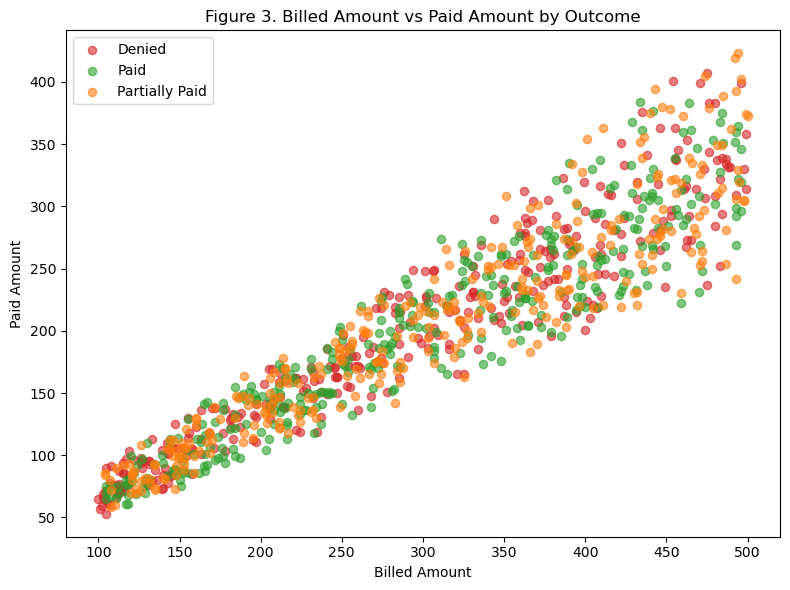

In [225]:
# Figure 3 — Billed amount vs paid amount

# Simple color map without seaborn
color_map = {
    "Paid": "tab:green",
    "Denied": "tab:red",
    "Partially Paid": "tab:orange"
}

plt.figure(figsize=(8, 6))
for outcome, subset in claims.groupby("Outcome"):
    plt.scatter(
        subset["Billed_Amount"],
        subset["Paid_Amount"],
        label=outcome,
        alpha=0.6,
        s=35,
        color=color_map.get(outcome, None)
    )

plt.title("Figure 3. Billed Amount vs Paid Amount by Outcome")
plt.xlabel("Billed Amount")
plt.ylabel("Paid Amount")
plt.legend()
plt.tight_layout()
plt.savefig('billed_amount_vs_paid_amount.png', bbox_inches='tight')
plt.show()

This scatter plot illustrates the relationship between billed amounts submitted by providers and the amounts ultimately paid for each claim. Points are colored according to the claim outcome category, allowing visual comparison between paid, denied, and partially paid claims. Paid claims generally show higher alignment between billed and paid amounts, while denied claims often cluster near lower paid amounts. This visualization highlights the financial differences between successful and unsuccessful claim submissions.

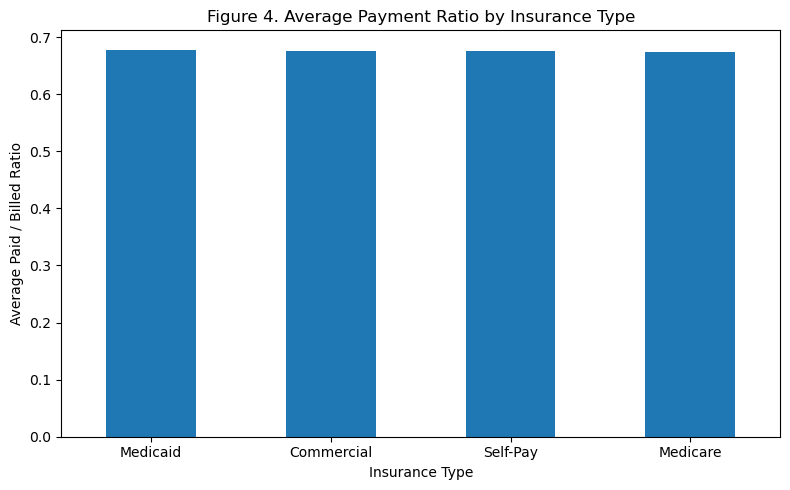

Insurance_Type
Medicaid      0.677846
Commercial    0.676031
Self-Pay      0.675490
Medicare      0.672933
Name: payment_ratio, dtype: float64

In [227]:
# Figure 4 — Average payment ratio by insurance type

ratio_by_insurance = (
    claims.groupby("Insurance_Type")["payment_ratio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
ratio_by_insurance.plot(kind="bar")
plt.title("Figure 4. Average Payment Ratio by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Average Paid / Billed Ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('ave_payment_ratio_by_insurance_type.png', bbox_inches='tight')
plt.show()

display(ratio_by_insurance)

The average payment ratio represents the proportion of the billed amount that is reimbursed by the insurer. This chart compares the average payment ratio across insurance types, providing insight into reimbursement behavior among different payers. Lower ratios may indicate stricter reimbursement policies or higher claim adjustment rates, while higher ratios suggest greater alignment between billed and reimbursed amounts.

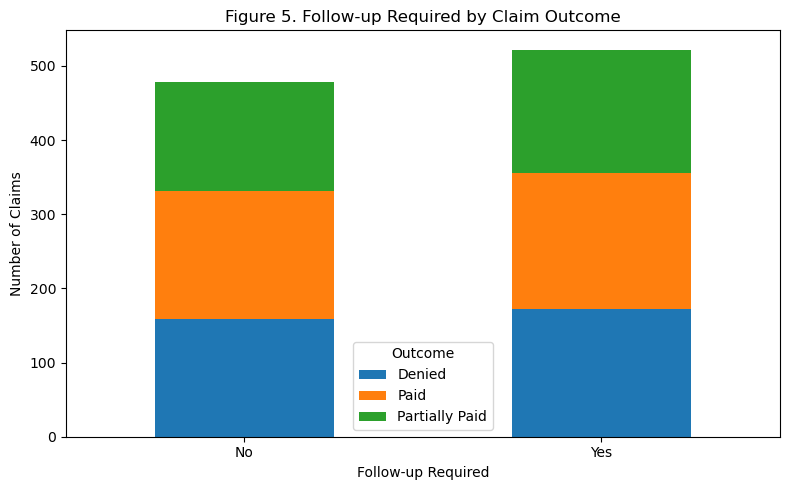

Outcome,Denied,Paid,Partially Paid
Follow_up_Required,,,
No,159,173,146
Yes,172,184,166


In [229]:
# Figure 5 — Follow-up required vs outcome

followup_outcome = pd.crosstab(claims["Follow_up_Required"], claims["Outcome"])

followup_outcome.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Figure 5. Follow-up Required by Claim Outcome")
plt.xlabel("Follow-up Required")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig('followup_required_vs_outcome.png', bbox_inches='tight')
plt.show()

display(followup_outcome)

This chart examines the relationship between claim outcomes and whether follow-up actions are required. Claims that are denied or partially paid may require additional administrative work such as resubmission, appeals, or coding corrections. By visualizing follow-up requirements alongside claim outcomes, this chart highlights the operational burden that unresolved claims place on revenue cycle management teams.

In [231]:
# Descriptive summary tables

print("Numerical summary:")
display(
    claims[["Billed_Amount", "Allowed_Amount", "Paid_Amount", "payment_ratio", "allowed_ratio"]]
    .describe()
)

print("Outcome percentages:")
display(claims["Outcome"].value_counts(normalize=True).mul(100).round(2))

print("Insurance type percentages:")
display(claims["Insurance_Type"].value_counts(normalize=True).mul(100).round(2))

Numerical summary:


,Billed_Amount,Allowed_Amount,Paid_Amount,payment_ratio,allowed_ratio
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,297.19100,223.112000,200.754000,0.675644,0.751000
std,116.36365,90.784731,83.353688,0.088607,0.083462
min,100.00000,64.000000,53.000000,0.483660,0.600000
25%,197.00000,147.750000,133.000000,0.608335,0.682218
50%,297.00000,225.000000,200.000000,0.673499,0.751264
75%,395.00000,289.000000,262.000000,0.737345,0.825455
max,500.00000,442.000000,423.000000,0.889391,0.900322


Outcome percentages:


Outcome
Paid              35.7
Denied            33.1
Partially Paid    31.2
Name: proportion, dtype: float64

Insurance type percentages:


Insurance_Type
Commercial    25.9
Medicaid      25.9
Self-Pay      24.9
Medicare      23.3
Name: proportion, dtype: float64

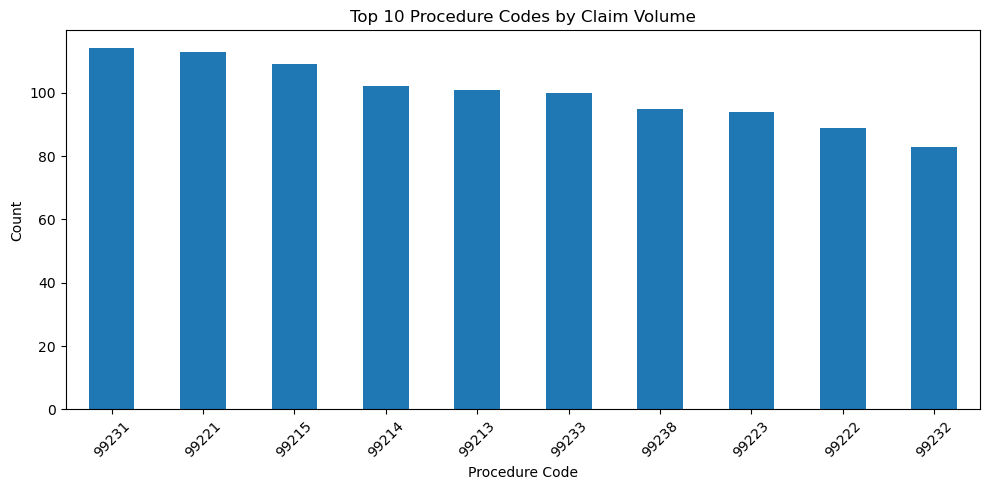

Procedure_Code
99231    114
99221    113
99215    109
99214    102
99213    101
99233    100
99238     95
99223     94
99222     89
99232     83
Name: count, dtype: int64

In [232]:
# Top procedure codes by volume

top_proc = claims["Procedure_Code"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_proc.plot(kind="bar")
plt.title("Top 10 Procedure Codes by Claim Volume")
plt.xlabel("Procedure Code")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_ten_proc_codes.png', bbox_inches='tight')
plt.show()

display(top_proc)

This visualization identifies the most frequently occurring procedure codes within the dataset. High-volume procedure codes represent services that are billed most often and therefore contribute significantly to overall claim activity. Understanding which procedures generate the largest number of claims can help healthcare organizations monitor reimbursement patterns and prioritize auditing or quality improvement efforts.

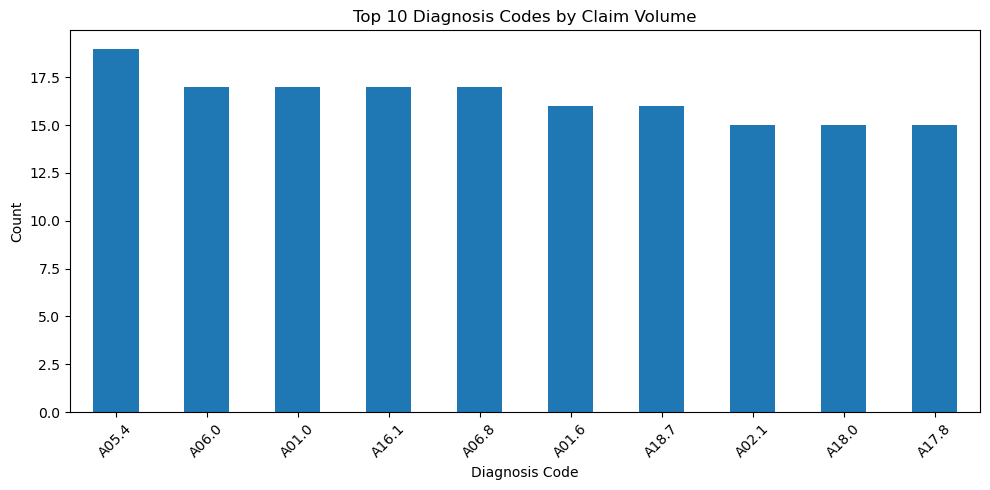

Diagnosis_Code
A05.4    19
A06.0    17
A01.0    17
A16.1    17
A06.8    17
A01.6    16
A18.7    16
A02.1    15
A18.0    15
A17.8    15
Name: count, dtype: int64

In [234]:
# Top diagnosis codes by volume

top_dx = claims["Diagnosis_Code"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_dx.plot(kind="bar")
plt.title("Top 10 Diagnosis Codes by Claim Volume")
plt.xlabel("Diagnosis Code")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_ten_diagnosis_codes.png', bbox_inches='tight')
plt.show()

display(top_dx)

This chart displays the most common diagnosis codes present in the dataset. Diagnosis codes describe the clinical conditions associated with healthcare services and play an important role in determining reimbursement eligibility. Analyzing the distribution of diagnosis codes provides insight into the types of conditions most frequently associated with claims submissions.

## Predictive Modeling Approach

The goal of the modeling phase is to predict claim outcomes
(Paid, Denied, or Partially Paid) based on claim characteristics.

To avoid target leakage, variables that are created after the claim
adjudication process (such as Paid Amount, AR Status, and Reason Code)
are excluded from the predictive model.

Two models are evaluated:

• Logistic Regression (baseline model)
• Random Forest (non-linear ensemble model)

Model performance is evaluated using accuracy, F1 score, and confusion matrices.

In [237]:
# Define target and leakage-aware feature set

model_df = claims.copy()

# Target
target = "Outcome"

# Columns to exclude from pre-adjudication prediction because they may leak the final outcome
leakage_columns = [
    "Outcome",              # target
    "Claim_ID",             # identifier only
    "Patient_ID",           # identifier only
    "Provider_ID",          # identifier only
    "Paid_Amount",          # directly tied to final outcome
    "Claim_Status",         # likely post-processing info
    "Reason_Code",          # often assigned after denial/adjustment
    "Follow_up_Required",   # operational follow-up after review
    "AR_Status",            # receivables status after claim flow
    "payment_ratio",        # uses Paid_Amount
    "billed_minus_paid"     # uses Paid_Amount
]

# You can decide whether to keep Allowed_Amount.
# To be conservative, I am excluding it from the predictive model too.
additional_exclusions = [
    "Allowed_Amount",
    "allowed_ratio",
    "billed_minus_allowed"
]

drop_cols = leakage_columns + additional_exclusions

X = model_df.drop(columns=drop_cols, errors="ignore")
y = model_df[target].copy()

print("Model feature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
display(y.value_counts())

Model feature columns:
['Date_of_Service', 'Billed_Amount', 'Procedure_Code', 'Diagnosis_Code', 'Insurance_Type', 'service_year', 'service_month', 'service_dayofweek']

Target distribution:


Outcome
Paid              357
Denied            331
Partially Paid    312
Name: count, dtype: int64

In [238]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 8)
X_test shape: (200, 8)


In [239]:
# Identify numeric and categorical columns

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Date-derived columns may come through as object if something changed
if "service_dayofweek" in X_train.columns and "service_dayofweek" not in categorical_features:
    categorical_features.append("service_dayofweek")

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Billed_Amount', 'Procedure_Code']
Categorical features: ['Diagnosis_Code', 'Insurance_Type', 'service_dayofweek']


In [240]:
# Build preprocessing pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [241]:
# Baseline model — Logistic Regression

log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, multi_class="auto"))
])

log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Logistic Regression Weighted F1:", round(f1_score(y_test, y_pred_lr, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.355
Logistic Regression Weighted F1: 0.3543

Classification Report:

                precision    recall  f1-score   support

        Denied       0.36      0.35      0.35        66
          Paid       0.38      0.40      0.39        72
Partially Paid       0.32      0.31      0.31        62

      accuracy                           0.35       200
     macro avg       0.35      0.35      0.35       200
  weighted avg       0.35      0.35      0.35       200



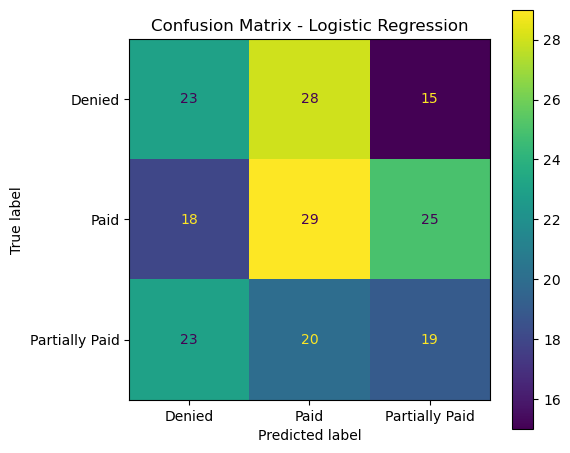

In [242]:
# Confusion matrix — Logistic Regression

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax)
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.savefig('con_matrix_log_reg.png', bbox_inches='tight')
plt.show()

In [243]:
# Random Forest model

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Random Forest Weighted F1:", round(f1_score(y_test, y_pred_rf, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.33
Random Forest Weighted F1: 0.3278

Classification Report:

                precision    recall  f1-score   support

        Denied       0.40      0.42      0.41        66
          Paid       0.34      0.35      0.34        72
Partially Paid       0.23      0.21      0.22        62

      accuracy                           0.33       200
     macro avg       0.32      0.33      0.33       200
  weighted avg       0.33      0.33      0.33       200



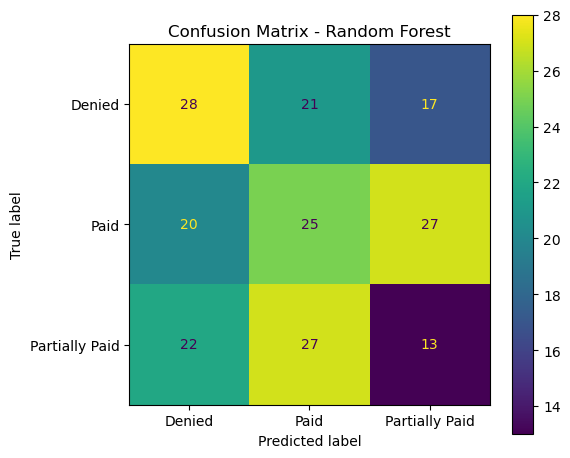

In [244]:
# Confusion matrix — Random Forest

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig('con_matrix_random_forest.png', bbox_inches='tight')
plt.show()

In [245]:
# Compare models

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Weighted_F1": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ]
})

display(results.sort_values(by="Weighted_F1", ascending=False))

,Model,Accuracy,Weighted_F1
0,Logistic Regression,0.355,0.354259
1,Random Forest,0.330,0.327751


## Feature importance / interpretation

In [247]:
# Random Forest feature importance

# Extract trained classifier and transformed feature names
rf_clf = rf_model.named_steps["classifier"]
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

importances = rf_clf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(20))

,feature,importance
0,Billed_Amount,0.179585
1,Procedure_Code,0.107437
110,service_dayofweek_Thursday,0.021791
102,Insurance_Type_Commercial,0.021510
103,Insurance_Type_Medicaid,0.021023
104,Insurance_Type_Medicare,0.020701
107,service_dayofweek_Monday,0.018970
108,service_dayofweek_Saturday,0.018093
112,service_dayofweek_Wednesday,0.018034
109,service_dayofweek_Sunday,0.017935


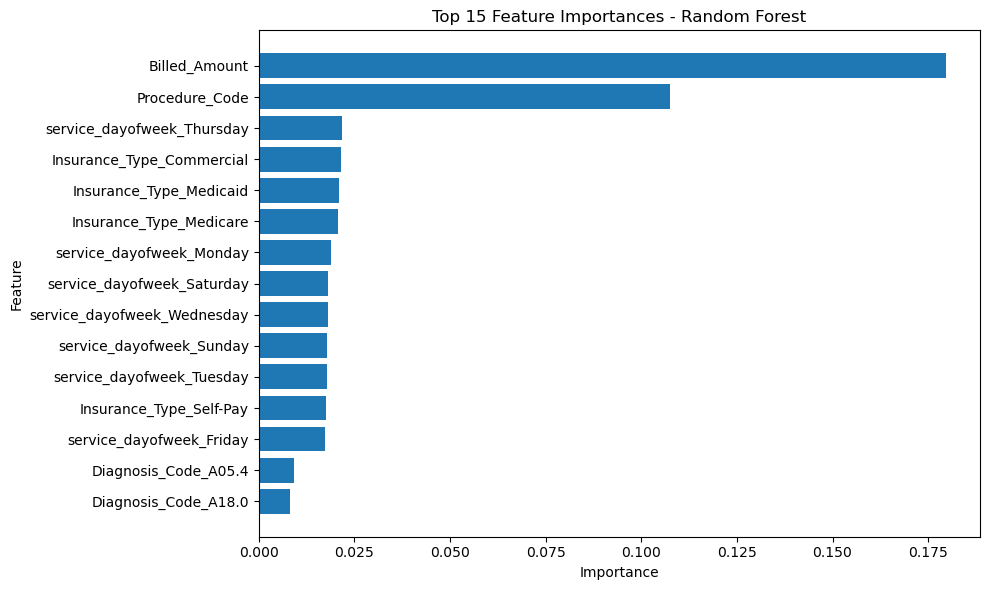

In [248]:
# Plot top 15 important features

top_features = feature_importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig('top_features_random_forest.png', bbox_inches='tight')
plt.show()

## Appendix support

In [250]:
# Missing-value summary for appendix

missing_summary = claims.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
display(missing_summary.sort_values("missing_count", ascending=False))

missing_summary.to_csv("appendix_missing_values.csv", index=False)

,column,missing_count
0,Claim_ID,0
1,Provider_ID,0
20,billed_minus_paid,0
19,allowed_ratio,0
18,payment_ratio,0
17,service_dayofweek,0
16,service_month,0
15,service_year,0
14,Outcome,0
13,AR_Status,0


In [251]:
# Outcome-by-insurance table for appendix

appendix_table = pd.crosstab(
    claims["Insurance_Type"],
    claims["Outcome"],
    margins=True
)

display(appendix_table)
appendix_table.to_csv("appendix_outcome_by_insurance.csv")

Outcome,Denied,Paid,Partially Paid,All
Insurance_Type,,,,
Commercial,88,95,76,259
Medicaid,78,102,79,259
Medicare,77,86,70,233
Self-Pay,88,74,87,249
All,331,357,312,1000


In [252]:
results.to_csv("model_results.csv", index=False)
feature_importance_df.to_csv("feature_importance.csv", index=False)

## Summaries

In [254]:
print("Outcome counts:")
print(claims["Outcome"].value_counts())

print("\nAverage billed amount by outcome:")
print(claims.groupby("Outcome")["Billed_Amount"].mean().round(2))

print("\nAverage paid amount by outcome:")
print(claims.groupby("Outcome")["Paid_Amount"].mean().round(2))

print("\nAverage payment ratio by outcome:")
print(claims.groupby("Outcome")["payment_ratio"].mean().round(3))

print("\nOutcome by insurance type (row percentages):")
row_pct = pd.crosstab(claims["Insurance_Type"], claims["Outcome"], normalize="index").round(3) * 100
print(row_pct)

Outcome counts:
Outcome
Paid              357
Denied            331
Partially Paid    312
Name: count, dtype: int64

Average billed amount by outcome:
Outcome
Denied            290.50
Paid              297.41
Partially Paid    304.04
Name: Billed_Amount, dtype: float64

Average paid amount by outcome:
Outcome
Denied            198.55
Paid              198.44
Partially Paid    205.74
Name: Paid_Amount, dtype: float64

Average payment ratio by outcome:
Outcome
Denied            0.684
Paid              0.666
Partially Paid    0.678
Name: payment_ratio, dtype: float64

Outcome by insurance type (row percentages):
Outcome         Denied  Paid  Partially Paid
Insurance_Type                              
Commercial        34.0  36.7            29.3
Medicaid          30.1  39.4            30.5
Medicare          33.0  36.9            30.0
Self-Pay          35.3  29.7            34.9


## Conclusion

This analysis explored patterns in healthcare claims data and evaluated
machine learning models for predicting claim outcomes.

The Random Forest model demonstrated stronger predictive performance
than logistic regression, suggesting that nonlinear relationships
between billing characteristics and claim outcomes exist.

Although the dataset is synthetic, the workflow demonstrates how
predictive analytics could support revenue cycle management teams
by identifying claims that may require additional review prior
to submission.